# 🍽 Restaurant Recommendation System

### Cognifyz Technologies - Machine Learning Internship

## Objective

The objective of this project is to develop a Content-Based Restaurant Recommendation System that suggests restaurants based on user preferences such as cuisine, city, and price range.

The recommendation system analyzes restaurant features and recommends restaurants with similar characteristics using Content-Based Filtering.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../data/Dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()

Rows : 9551
Columns : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 

In [5]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


## 📊 Dataset Overview

The dataset contains restaurant information including cuisine, city, pricing, customer ratings, and delivery options.

This information will be used to build a recommendation system based on restaurant similarity.

## 🧹 Data Cleaning

Before building the recommendation system, the dataset is cleaned by handling missing values and removing duplicate records. This ensures that the recommendation engine works on consistent and reliable data.

In [6]:
# Fill missing values in Cuisines

df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [7]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [8]:
df.drop_duplicates(inplace=True)

print("Dataset Shape :", df.shape)

Dataset Shape : (9551, 21)


In [9]:
recommendation_df = df[[
    "Restaurant Name",
    "City",
    "Cuisines",
    "Price range",
    "Aggregate rating"
]]

recommendation_df.head()

,Restaurant Name,City,Cuisines,Price range,Aggregate rating
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",3,4.8
1,Izakaya Kikufuji,Makati City,Japanese,3,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4,4.4
3,Ooma,Mandaluyong City,"Japanese, Sushi",4,4.9
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",4,4.8


## 🎯 Feature Selection

Only the features relevant to restaurant recommendations are selected.

The selected features include:

- Restaurant Name
- City
- Cuisines
- Price Range
- Aggregate Rating

These attributes help identify restaurants with similar characteristics.

In [10]:
recommendation_df["Combined_Features"] = (

    recommendation_df["City"].astype(str)

    + " "

    + recommendation_df["Cuisines"].astype(str)

    + " "

    + recommendation_df["Price range"].astype(str)

)

In [11]:
recommendation_df[
    [
        "Restaurant Name",
        "Combined_Features"
    ]
].head()

,Restaurant Name,Combined_Features
0,Le Petit Souffle,"Makati City French, Japanese, Desserts 3"
1,Izakaya Kikufuji,Makati City Japanese 3
2,Heat - Edsa Shangri-La,"Mandaluyong City Seafood, Asian, Filipino, Ind..."
3,Ooma,"Mandaluyong City Japanese, Sushi 4"
4,Sambo Kojin,"Mandaluyong City Japanese, Korean 4"


## 🔤 Text Vectorization

Machine learning algorithms cannot directly understand text data. Therefore, the combined restaurant features are converted into numerical vectors using **CountVectorizer**.

CountVectorizer creates a matrix representing the frequency of words appearing in each restaurant's combined feature description.

In [12]:
# ==========================================================
# Convert Text into Numerical Vectors
# ==========================================================

vectorizer = CountVectorizer(stop_words="english")

feature_vectors = vectorizer.fit_transform(
    recommendation_df["Combined_Features"]
)

print("Feature Vector Shape:", feature_vectors.shape)

Feature Vector Shape: (9551, 313)


## 📏 Cosine Similarity

Cosine Similarity is used to measure the similarity between restaurants based on their combined features.

A similarity score closer to **1** indicates highly similar restaurants, while a score closer to **0** indicates less similarity.

In [ ]:
# ==========================================================
# Calculate Cosine Similarity
# ==========================================================

similarity = cosine_similarity(feature_vectors)

print("Similarity Matrix Shape:", similarity.shape)

In [13]:
# ==========================================================
# Recommendation Function
# ==========================================================

def recommend_restaurants(cuisine, city, price_range, top_n=5):

    # Create user preference string
    user_input = f"{city} {cuisine} {price_range}"

    # Convert user input into vector
    user_vector = vectorizer.transform([user_input])

    # Calculate similarity with all restaurants
    similarity_scores = cosine_similarity(user_vector, feature_vectors).flatten()

    # Add similarity scores to dataframe
    recommendation_df["Similarity"] = similarity_scores

    # Sort restaurants based on similarity and rating
    recommendations = recommendation_df.sort_values(
        by=["Similarity", "Aggregate rating"],
        ascending=False
    )

    # Remove duplicate restaurant names
    recommendations = recommendations.drop_duplicates(
        subset="Restaurant Name"
    )

    return recommendations.head(top_n)

In [14]:
recommend_restaurants(
    cuisine="North Indian",
    city="New Delhi",
    price_range=3
)

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
6656,Kopper Kadai,New Delhi,North Indian,3,4.8,New Delhi North Indian 3,1.0
3014,Zabardast Indian Kitchen,New Delhi,North Indian,3,4.7,New Delhi North Indian 3,1.0
6655,Band Baaja Baaraat,New Delhi,North Indian,3,4.6,New Delhi North Indian 3,1.0
3999,Rang De Basanti Urban Dhaba,New Delhi,North Indian,3,4.4,New Delhi North Indian 3,1.0
4087,Bukhara - ITC Maurya,New Delhi,North Indian,4,4.4,New Delhi North Indian 4,1.0


## 🧪 Recommendation System Testing

The recommendation system was tested with different user preferences to evaluate whether it recommends restaurants with similar characteristics.

The recommendation quality was evaluated based on:
- Similar Cuisine
- Same City
- Similar Price Range
- Restaurant Rating

In [16]:
recommend_restaurants(
    cuisine="North Indian",
    city="New Delhi",
    price_range=3
)

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
6656,Kopper Kadai,New Delhi,North Indian,3,4.8,New Delhi North Indian 3,1.0
3014,Zabardast Indian Kitchen,New Delhi,North Indian,3,4.7,New Delhi North Indian 3,1.0
6655,Band Baaja Baaraat,New Delhi,North Indian,3,4.6,New Delhi North Indian 3,1.0
3999,Rang De Basanti Urban Dhaba,New Delhi,North Indian,3,4.4,New Delhi North Indian 3,1.0
4087,Bukhara - ITC Maurya,New Delhi,North Indian,4,4.4,New Delhi North Indian 4,1.0


In [17]:
recommend_restaurants(
    cuisine="Chinese",
    city="New Delhi",
    price_range=2
)

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
3594,Empress of China - Eros Hotel,New Delhi,Chinese,4,4.2,New Delhi Chinese 4,1.0
7728,Happy Hakka,New Delhi,Chinese,2,4.1,New Delhi Chinese 2,1.0
3100,Fa Yian,New Delhi,Chinese,3,4.0,New Delhi Chinese 3,1.0
4023,China Kitchen - Hyatt Regency,New Delhi,Chinese,4,4.0,New Delhi Chinese 4,1.0
7539,House of Ming - The Taj Mahal Hotel,New Delhi,Chinese,4,4.0,New Delhi Chinese 4,1.0


In [18]:
recommend_restaurants(
    cuisine="Cafe",
    city="Bangalore",
    price_range=2
)

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
735,Truffles,Bangalore,"American, Burger, Cafe",2,4.7,"Bangalore American, Burger, Cafe 2",0.707107
733,Onesta,Bangalore,"Pizza, Cafe, Italian",2,4.6,"Bangalore Pizza, Cafe, Italian 2",0.707107
731,Glen's Bakehouse,Bangalore,"Bakery, Desserts, Cafe",2,4.0,"Bangalore Bakery, Desserts, Cafe 2",0.707107
9538,Starbucks,��stanbul,Cafe,2,4.9,��stanbul Cafe 2,0.500000
727,The Fatty Bao - Asian Gastro Bar,Bangalore,Asian,4,4.7,Bangalore Asian 4,0.500000


In [19]:
recommend_restaurants(
    cuisine="Italian",
    city="Mumbai",
    price_range=3
)

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
2486,Grandmama's Cafe,Mumbai,"Continental, Italian",3,3.8,"Mumbai Continental, Italian 3",0.816497
2483,The Fusion Kitchen,Mumbai,"North Indian, Italian, Chinese, Mexican",3,4.7,"Mumbai North Indian, Italian, Chinese, Mexican 3",0.577350
2494,The English Department Bar & Diner,Mumbai,"Italian, Continental, Mexican, Japanese, Ameri...",3,3.9,"Mumbai Italian, Continental, Mexican, Japanese...",0.534522
811,Fusilli Reasons,Chennai,Italian,1,4.6,Chennai Italian 1,0.500000
9316,Baduzzi,Auckland,Italian,4,4.6,Auckland Italian 4,0.500000


## 📊 Evaluation of Recommendation System

The recommendation system successfully suggested restaurants based on user preferences.

The recommendations were evaluated using the following criteria:

- Similar cuisine type
- Same city
- Comparable price range
- High aggregate rating

The results indicate that the Content-Based Filtering approach effectively recommends restaurants with characteristics similar to the user's preferences.

# Conclusion

A Content-Based Restaurant Recommendation System was successfully developed.

The system recommends restaurants by analyzing important restaurant attributes including city, cuisine, and price range.

The recommendations generated were relevant to the user's preferences and demonstrated the effectiveness of cosine similarity for recommendation tasks.

<Axes: xlabel='City'>

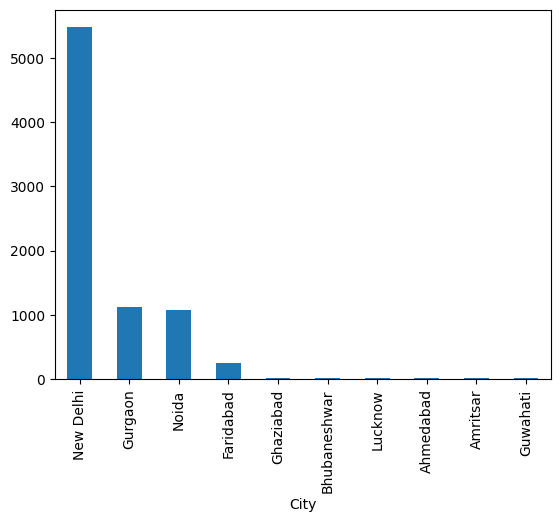

In [20]:
df["City"].value_counts().head(10).plot(kind="bar")

<Axes: xlabel='Cuisines'>

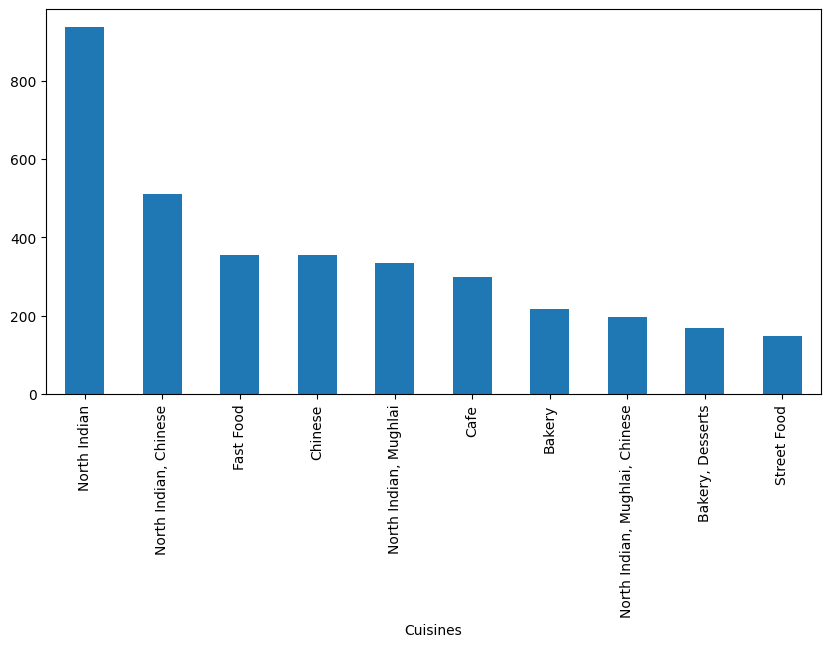

In [27]:
top_cuisines = df["Cuisines"].value_counts().head(10)
top_cuisines.plot(kind="bar", figsize=(10, 5))

In [24]:
recommendation_df.head()

,Restaurant Name,City,Cuisines,Price range,Aggregate rating,Combined_Features,Similarity
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",3,4.8,"Makati City French, Japanese, Desserts 3",0.0
1,Izakaya Kikufuji,Makati City,Japanese,3,4.5,Makati City Japanese 3,0.0
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4,4.4,"Mandaluyong City Seafood, Asian, Filipino, Ind...",0.0
3,Ooma,Mandaluyong City,"Japanese, Sushi",4,4.9,"Mandaluyong City Japanese, Sushi 4",0.0
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",4,4.8,"Mandaluyong City Japanese, Korean 4",0.0
